In [4]:
# ============================================
# BLOCK 1: KHAI BÁO THƯ VIỆN VÀ DỮ LIỆU
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree


# 1. Dataset
data = {
    'Age': [25, 40, 35, 27, 31, 36, 48, 26, 33, 29, 38, 44, 42, 28, 30],

    'Marital_Status': [
        'Single', 'Married', 'Divorced', 'Married', 'Single',
        'Married', 'Single', 'Married', 'Divorced', 'Single',
        'Married', 'Single', 'Married', 'Single', 'Married'
    ],

    'Housing': [
        'Parents', 'Own', 'Rent', 'Parents', 'Rent',
        'Own', 'Rent', 'Rent', 'Parents', 'Rent',
        'Own', 'Own', 'Own', 'Rent', 'Parents'
    ],

    'Income': [
        7000000, 18000000, 12000000, 9000000, 6000000,
        8000000, 7000000, 8000000, 5000000, 10000000,
        15000000, 14000000, 10000000, 7000000, 6000000
    ],

    'Credit_Risk': [
        0, 0, 1, 1, 1,
        1, 0, 1, 1, 0,
        0, 1, 0, 1, 1
    ]
}

df = pd.DataFrame(data)


# 2. Chia nhóm các biến liên tục
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 100],
    labels=['Young', 'Middle', 'Senior']
)

df['Income_Group'] = pd.cut(
    df['Income'],
    bins=[0, 7000000, 12000000, np.inf],
    labels=['Low', 'Medium', 'High']
)


# 3. Chọn biến đầu vào và biến mục tiêu
X = df[['Age_Group', 'Marital_Status', 'Housing', 'Income_Group']]
y = df['Credit_Risk']

# Chuyển biến dạng chữ thành biến số 0/1
X_encoded = pd.get_dummies(X)

print("Dữ liệu:")
display(df)

Dữ liệu:


,Age,Marital_Status,Housing,Income,Credit_Risk,Age_Group,Income_Group
0,25,Single,Parents,7000000,0,Young,Low
1,40,Married,Own,18000000,0,Middle,High
2,35,Divorced,Rent,12000000,1,Middle,Medium
3,27,Married,Parents,9000000,1,Young,Medium
4,31,Single,Rent,6000000,1,Middle,Low
5,36,Married,Own,8000000,1,Middle,Medium
6,48,Single,Rent,7000000,0,Senior,Low
7,26,Married,Rent,8000000,1,Young,Medium
8,33,Divorced,Parents,5000000,1,Middle,Low
9,29,Single,Rent,10000000,0,Young,Medium


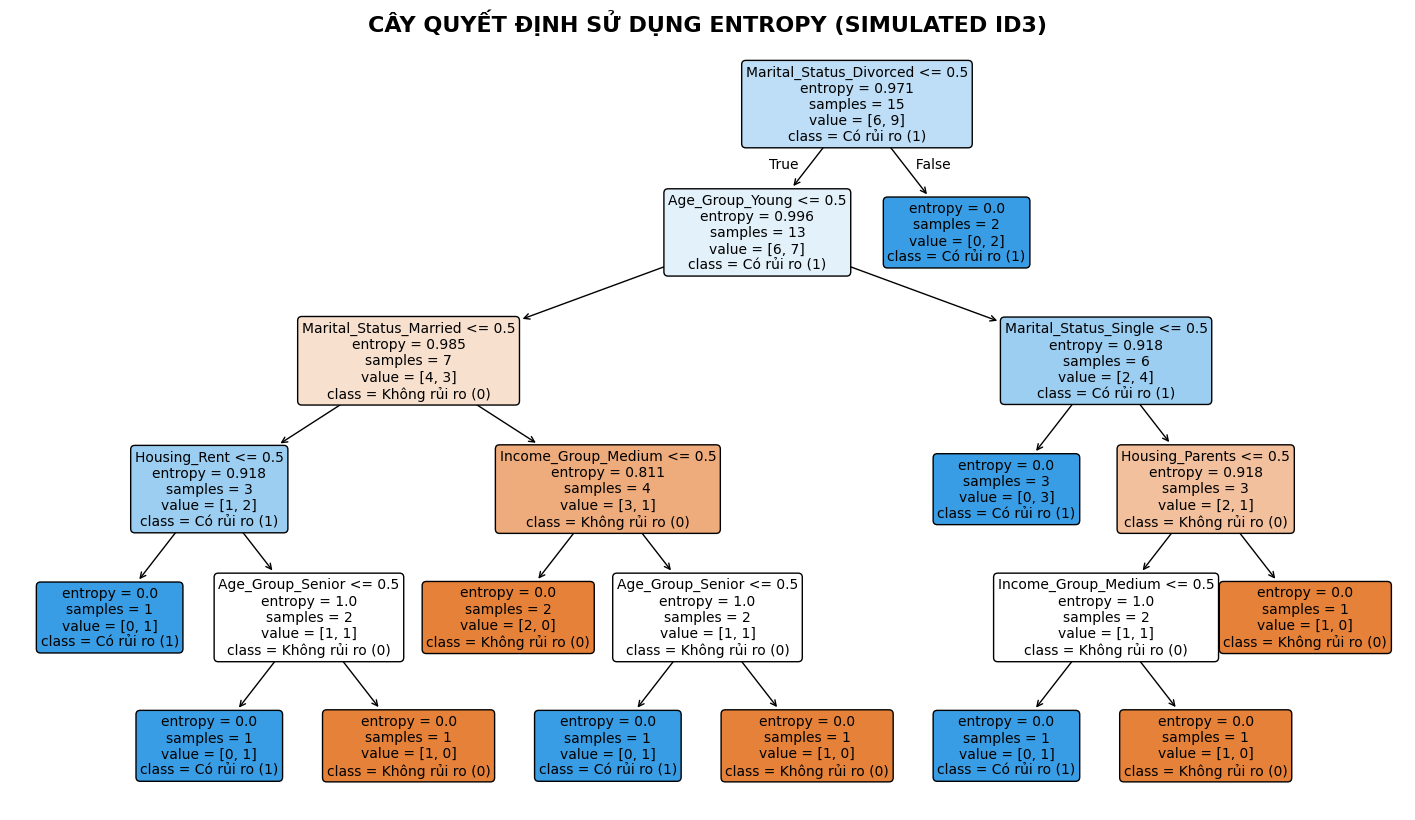

In [5]:
# ============================================
# BLOCK 2: SIMULATED ID3
# ============================================

# Decision Tree sử dụng Entropy
# Entropy là tiêu chí được ID3 sử dụng để chọn thuộc tính tốt nhất

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model.fit(X_encoded, y)


# Vẽ cây quyết định
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns.tolist(),

    # Hiển thị tên lớp bằng tiếng Việt
    class_names=['Không rủi ro (0)', 'Có rủi ro (1)'],

    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "CÂY QUYẾT ĐỊNH SỬ DỤNG ENTROPY (SIMULATED ID3)",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [6]:
# ============================================
# BLOCK 3: THUẬT TOÁN ID3
# ============================================

# Dataset đã được chia nhóm
data = {
    'Age': [
        'Young', 'Senior', 'Middle', 'Young', 'Middle',
        'Middle', 'Senior', 'Young', 'Middle', 'Young',
        'Middle', 'Senior', 'Senior', 'Young', 'Young'
    ],

    'Marital': [
        'Single', 'Married', 'Divorced', 'Married', 'Single',
        'Married', 'Single', 'Married', 'Divorced', 'Single',
        'Married', 'Single', 'Married', 'Single', 'Married'
    ],

    'Housing': [
        'Parents', 'Own', 'Rent', 'Parents', 'Rent',
        'Own', 'Rent', 'Rent', 'Parents', 'Rent',
        'Own', 'Own', 'Own', 'Rent', 'Parents'
    ],

    'Income': [
        'Low', 'High', 'Medium', 'Medium', 'Low',
        'Medium', 'Low', 'Medium', 'Low', 'Medium',
        'High', 'High', 'Medium', 'Low', 'Low'
    ],

    'Credit_Risk': [
        0, 0, 1, 1, 1,
        1, 0, 1, 1, 0,
        0, 1, 0, 1, 1
    ]
}

df_id3 = pd.DataFrame(data)


# --------------------------------------------
# 1. Tính Entropy
# --------------------------------------------

def calculate_entropy(target_col):

    values, counts = np.unique(
        target_col,
        return_counts=True
    )

    probabilities = counts / counts.sum()

    # Công thức Entropy
    return -np.sum(
        probabilities * np.log2(probabilities)
    )


# --------------------------------------------
# 2. Tính Information Gain
# --------------------------------------------

def calculate_information_gain(
    data_subset,
    feature,
    target_name
):

    # Entropy của toàn bộ dữ liệu
    total_entropy = calculate_entropy(
        data_subset[target_name]
    )

    # Các giá trị khác nhau của thuộc tính
    vals, counts = np.unique(
        data_subset[feature],
        return_counts=True
    )

    # Entropy có trọng số
    weighted_entropy = 0

    for i in range(len(vals)):

        sub_data = data_subset[
            data_subset[feature] == vals[i]
        ]

        entropy = calculate_entropy(
            sub_data[target_name]
        )

        weighted_entropy += (
            counts[i] / np.sum(counts)
        ) * entropy

    # Information Gain
    return total_entropy - weighted_entropy


# --------------------------------------------
# 3. Thuật toán ID3
# --------------------------------------------

def id3(
    data_subset,
    original_data,
    features,
    target_name='Credit_Risk'
):

    # Trường hợp tất cả dữ liệu cùng một lớp
    if len(np.unique(data_subset[target_name])) <= 1:
        return np.unique(data_subset[target_name])[0]


    # Không còn dữ liệu
    elif len(data_subset) == 0:

        values, counts = np.unique(
            original_data[target_name],
            return_counts=True
        )

        return values[np.argmax(counts)]


    # Không còn thuộc tính để chia
    elif len(features) == 0:

        values, counts = np.unique(
            data_subset[target_name],
            return_counts=True
        )

        return values[np.argmax(counts)]


    # Tính Information Gain cho tất cả thuộc tính
    information_gains = [
        calculate_information_gain(
            data_subset,
            feature,
            target_name
        )
        for feature in features
    ]


    # Chọn thuộc tính có Information Gain lớn nhất
    best_feature_index = np.argmax(information_gains)

    best_feature = features[best_feature_index]


    # Tạo node mới
    tree_dict = {
        best_feature: {}
    }


    # Các thuộc tính còn lại
    remaining_features = [
        feature
        for feature in features
        if feature != best_feature
    ]


    # Tạo nhánh cho từng giá trị của thuộc tính
    for value in np.unique(data_subset[best_feature]):

        sub_data = data_subset[
            data_subset[best_feature] == value
        ]

        subtree = id3(
            sub_data,
            original_data,
            remaining_features,
            target_name
        )

        tree_dict[best_feature][value] = subtree


    return tree_dict


# --------------------------------------------
# 4. Chạy thuật toán ID3
# --------------------------------------------

features_list = [
    'Age',
    'Marital',
    'Housing',
    'Income'
]

tree = id3(
    df_id3,
    df_id3,
    features_list
)


print("Cây ID3:")
print(tree)

Cây ID3:
{'Age': {'Middle': {'Income': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(1)}}, 'Senior': {'Marital': {'Married': np.int64(0), 'Single': {'Housing': {'Own': np.int64(1), 'Rent': np.int64(0)}}}}, 'Young': {'Marital': {'Married': np.int64(1), 'Single': {'Housing': {'Parents': np.int64(0), 'Rent': {'Income': {'Low': np.int64(1), 'Medium': np.int64(0)}}}}}}}}


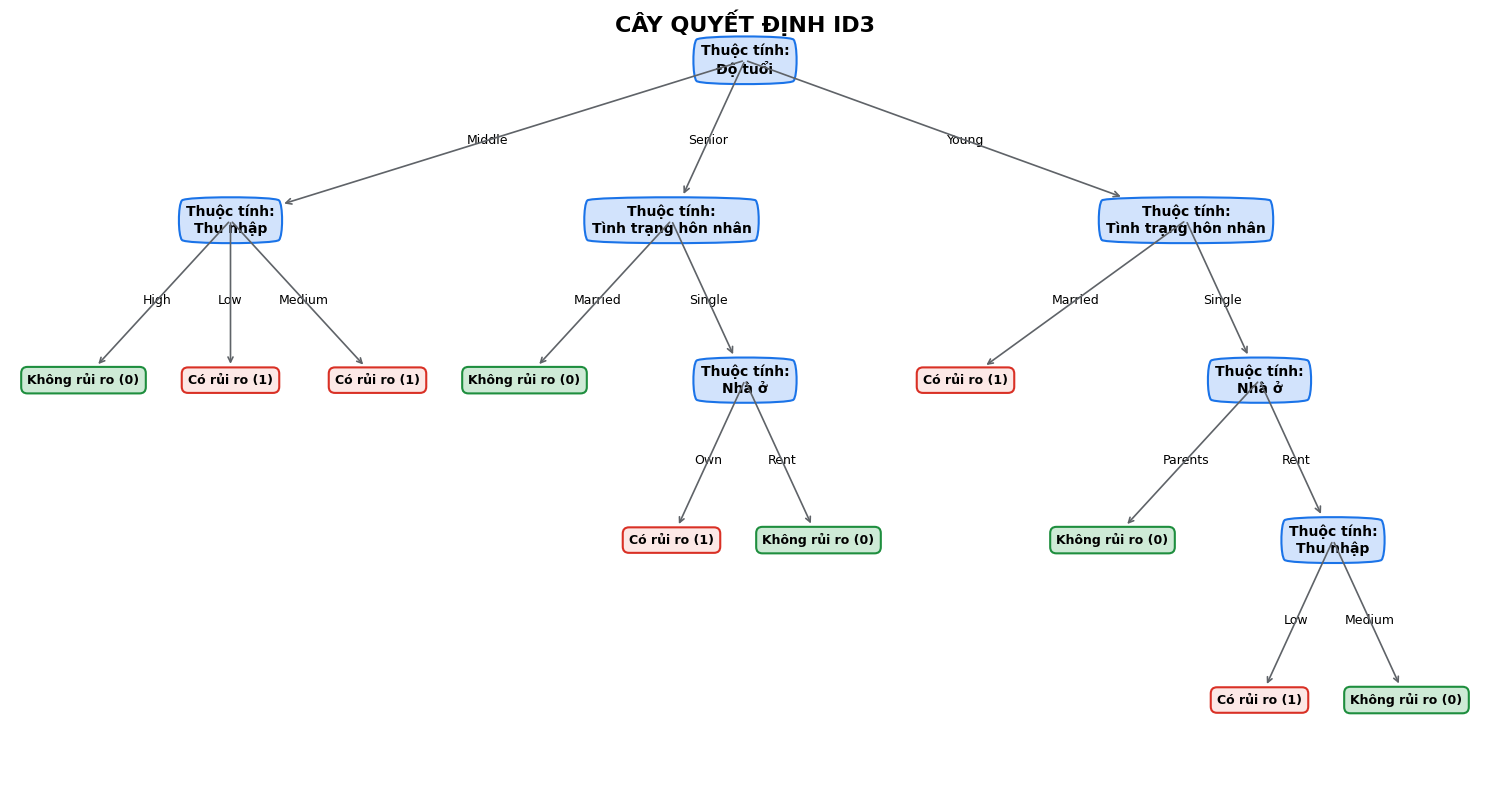

In [7]:
# ============================================
# BLOCK 4: VISUALIZE CÂY ID3
# ============================================

# --------------------------------------------
# 1. Đếm số node lá
# --------------------------------------------

def get_num_leafs(my_tree):

    num_leafs = 0

    first_feature = list(my_tree.keys())[0]
    second_dict = my_tree[first_feature]

    for key in second_dict.keys():

        if isinstance(second_dict[key], dict):
            num_leafs += get_num_leafs(second_dict[key])

        else:
            num_leafs += 1

    return num_leafs


# --------------------------------------------
# 2. Tính độ sâu của cây
# --------------------------------------------

def get_tree_depth(my_tree):

    max_depth = 0

    first_feature = list(my_tree.keys())[0]
    second_dict = my_tree[first_feature]

    for key in second_dict.keys():

        if isinstance(second_dict[key], dict):

            current_depth = (
                1 + get_tree_depth(second_dict[key])
            )

        else:
            current_depth = 1

        if current_depth > max_depth:
            max_depth = current_depth

    return max_depth


# --------------------------------------------
# 3. Style cho node
# --------------------------------------------

decision_node_style = dict(
    boxstyle="round4,pad=0.6",
    fc="#d2e3fc",
    ec="#1a73e8",
    lw=1.5
)

leaf_node_0_style = dict(
    boxstyle="round,pad=0.5",
    fc="#ceead6",
    ec="#1e8e3e",
    lw=1.5
)

leaf_node_1_style = dict(
    boxstyle="round,pad=0.5",
    fc="#fce8e6",
    ec="#d93025",
    lw=1.5
)

arrow_args = dict(
    arrowstyle="<-",
    color="#5f6368",
    lw=1.2
)


# --------------------------------------------
# 4. Hiển thị tên nhánh
# --------------------------------------------

def plot_mid_text(
    center_point,
    parent_point,
    text_string,
    ax
):

    x_mid = (
        parent_point[0] - center_point[0]
    ) / 2.0 + center_point[0]

    y_mid = (
        parent_point[1] - center_point[1]
    ) / 2.0 + center_point[1]

    ax.text(
        x_mid,
        y_mid,
        text_string,
        va="center",
        ha="center",
        fontsize=9,

        bbox=dict(
            boxstyle="square,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.8
        )
    )


# --------------------------------------------
# 5. Vẽ cây đệ quy
# --------------------------------------------

def plot_tree_recursive(
    my_tree,
    parent_point,
    node_text,
    ax,
    total_width,
    total_depth,
    plot_state
):

    num_leafs = get_num_leafs(my_tree)

    first_feature = list(my_tree.keys())[0]

    center_point = (
        plot_state['x_off']
        + (1.0 + float(num_leafs))
        / 2.0
        / total_width,

        plot_state['y_off']
    )


    # Hiển thị tên nhánh
    if node_text:

        plot_mid_text(
            center_point,
            parent_point,
            node_text,
            ax
        )


    # Đổi tên thuộc tính sang tiếng Việt
    feature_names_vn = {
        'Age': 'Độ tuổi',
        'Marital': 'Tình trạng hôn nhân',
        'Housing': 'Nhà ở',
        'Income': 'Thu nhập'
    }

    feature_vn = feature_names_vn.get(
        first_feature,
        first_feature
    )


    # Node quyết định
    ax.annotate(
        f"Thuộc tính:\n{feature_vn}",

        xy=parent_point,
        xycoords='axes fraction',

        xytext=center_point,
        textcoords='axes fraction',

        va="center",
        ha="center",

        bbox=decision_node_style,

        arrowprops=(
            arrow_args
            if node_text
            else None
        ),

        fontsize=10,
        weight='bold'
    )


    second_dict = my_tree[first_feature]

    plot_state['y_off'] -= (
        1.0 / total_depth
    )


    # Duyệt qua từng nhánh
    for key in second_dict.keys():

        if isinstance(
            second_dict[key],
            dict
        ):

            plot_tree_recursive(
                second_dict[key],
                center_point,
                str(key),
                ax,
                total_width,
                total_depth,
                plot_state
            )

        else:

            plot_state['x_off'] += (
                1.0 / total_width
            )

            leaf_value = second_dict[key]


            # Đổi kết quả sang tiếng Việt
            if leaf_value == 0:

                label = "Không rủi ro (0)"
                style = leaf_node_0_style

            else:

                label = "Có rủi ro (1)"
                style = leaf_node_1_style


            leaf_point = (
                plot_state['x_off'],
                plot_state['y_off']
            )


            # Hiển thị giá trị nhánh
            plot_mid_text(
                leaf_point,
                center_point,
                str(key),
                ax
            )


            # Node lá
            ax.annotate(
                label,

                xy=center_point,
                xycoords='axes fraction',

                xytext=leaf_point,
                textcoords='axes fraction',

                va="center",
                ha="center",

                bbox=style,

                arrowprops=arrow_args,

                fontsize=9,
                weight='bold'
            )


    plot_state['y_off'] += (
        1.0 / total_depth
    )


# --------------------------------------------
# 6. Hàm hiển thị cây
# --------------------------------------------

def render_id3_tree(tree_dict):

    fig, ax = plt.subplots(
        figsize=(15, 8)
    )

    ax.axis('off')


    total_width = float(
        get_num_leafs(tree_dict)
    )

    total_depth = float(
        get_tree_depth(tree_dict)
    ) + 0.5


    plot_state = {
        'x_off': -0.5 / total_width,
        'y_off': 1.0
    }


    plot_tree_recursive(
        tree_dict,
        (0.5, 1.0),
        '',
        ax,
        total_width,
        total_depth,
        plot_state
    )


    plt.title(
        "CÂY QUYẾT ĐỊNH ID3",
        fontsize=16,
        pad=20,
        weight='bold'
    )

    plt.tight_layout()

    plt.show()


# --------------------------------------------
# 7. Hiển thị cây
# --------------------------------------------

render_id3_tree(tree)